In [32]:
from transformers import AutoProcessor, AutoModelForSequenceClassification

from datasets import load_dataset
import torch
import cv2
import numpy as np
from PIL import Image
from PIL import Image, ImageDraw, ImageFont

processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)
model = AutoModelForSequenceClassification.from_pretrained("microsoft/layoutlmv3-base")

dataset = load_dataset("nielsr/funsd-layoutlmv3", split="train")


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 10791.96it/s]
[transformers] LayoutLMv3ForSequenceClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.weight    | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
example = dataset[0]
image = example["image"]
words = example["tokens"]
boxes = example["bboxes"]

In [43]:
example.keys()

dict_keys(['id', 'tokens', 'bboxes', 'ner_tags', 'image'])

In [47]:
example["id"], len(example["ner_tags"]),example["ner_tags"][:10]

('0', 145, [0, 3, 3, 3, 5, 3, 3, 0, 1, 2])

In [34]:
words[:11], boxes[:11]

(['R&D',
  ':',
  'Suggestion:',
  'Date:',
  'Licensee',
  'Yes',
  'No',
  '597005708',
  'R&D',
  'QUALITY',
  'IMPROVEMENT'],
 [[383, 91, 493, 175],
  [287, 316, 295, 327],
  [124, 355, 221, 370],
  [632, 268, 679, 282],
  [670, 309, 748, 323],
  [604, 605, 633, 619],
  [715, 603, 738, 617],
  [688, 904, 841, 926],
  [335, 201, 555, 229],
  [335, 201, 555, 229],
  [335, 201, 555, 229]])

In [42]:
len(words), len(boxes), len(set(tuple(box) for box in boxes))

(145, 145, 23)

In [36]:
# image.shape
isinstance(image, Image.Image)

True

In [37]:
def draw_bounding_boxes_pil(image, boxes, labels=None, colors=None):
    """
    使用 PIL 在图像上绘制边界框
    """
    # image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    img_width, img_height = image.size
    if colors is None:
        colors = ["red"] * len(boxes)
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        # ---------------------------------- 归一化坐标 begin----------------------------------
        px1 = int(x1 / 1000 * img_width)
        py1 = int(y1 / 1000 * img_height)
        px2 = int(x2 / 1000 * img_width)
        py2 = int(y2 / 1000 * img_height)

        x1, y1, x2, y2 = px1, py1, px2, py2
        # ---------------------------------- 归一化坐标 end----------------------------------
        draw.rectangle([x1, y1, x2, y2], outline=colors[i], width=3)
        
        if labels and i < len(labels):
            draw.text((x1, y1-10), str(labels[i]), fill=colors[i])
    
    return image

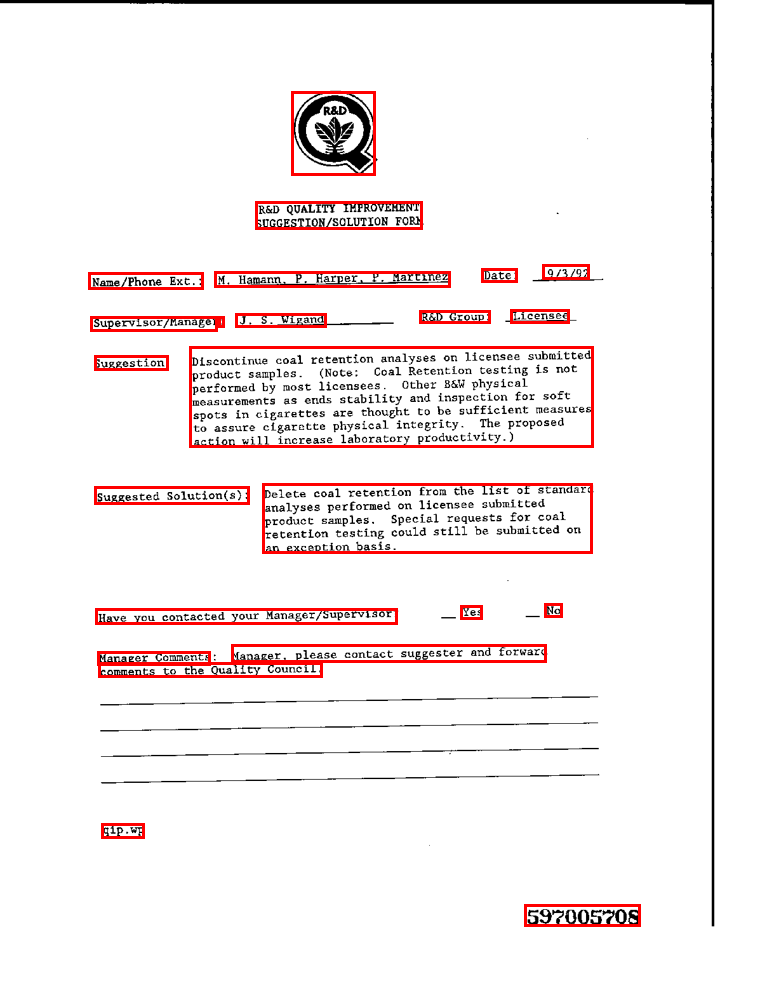

In [38]:
image_with_boxes = draw_bounding_boxes_pil(image, boxes)
image_with_boxes